In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_graphviz
from sklearn.impute import SimpleImputer

from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from sklearn.base import clone

import datetime
import xgboost as xgb

import numpy as np
import time
import datetime
import pydot
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt



# ĐỌC FILE CNTT_BATBUOC_DAXULY ở bước 1 tiền xử lý --> đưa vào dataframe tên là df
df = pd.read_csv('/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.1.TienXuLyDuLieu/lung_cancer_preprocessed.csv')

#in dữ liệu sau khi đọc từ file
print(df)

           AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0     0.682203       1        1                     1              1   
1     1.505110       1        1                     0              0   
2     0.049197       1        1                     0              0   
3    -0.837011       0        1                     0              1   
4     0.935405       0        1                     1              1   
...        ...     ...      ...                   ...            ...   
4995 -1.596618       0        1                     1              0   
4996  1.441810       0        1                     1              1   
4997 -0.393907       1        0                     0              1   
4998  1.188608       1        0                     1              0   
4999 -1.533317       0        1                     0              0   

      EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                         1                  0      0.

In [ ]:
#kiem tra du lieu các cột còn thiếu giá trị (đếm các cột trống có dữ liệu trống)
df.isna().sum()

,0
AGE,0
GENDER,0
SMOKING,0
FINGER_DISCOLORATION,0
MENTAL_STRESS,0
EXPOSURE_TO_POLLUTION,0
LONG_TERM_ILLNESS,0
ENERGY_LEVEL,0
IMMUNE_WEAKNESS,0
BREATHING_ISSUE,0


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


1. CATBOOST

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from catboost import Pool

# =========================
# 1 READ DATA
# =========================
# chuẩn hóa tên cột
df.columns = df.columns.str.strip().str.lower()
print("Columns:", df.columns.tolist())

# =========================
# 2 FEATURE / TARGET
# =========================
X = df.drop("pulmonary_disease", axis=1)
y = df["pulmonary_disease"]

# =========================
# 3 CHIA TRAIN / TEST
# =========================
X_train_full, X_test_final, y_train_full, y_test_final = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train_full.shape)
print("Test size :", X_test_final.shape)

# =========================
# 4 HUẤN LUYỆN CATBOOST TỐI ƯU NHẤT
# =========================
cat_full = CatBoostClassifier(
    iterations=100,
    depth=7,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    verbose=0,
    random_seed=42
)

cat_full.fit(X_train_full, y_train_full)

# =========================
# 5 ĐÁNH GIÁ HIỆU SUẤT BAN ĐẦU
# =========================
y_pred = cat_full.predict(X_test_final)
y_proba = cat_full.predict_proba(X_test_final)[:, 1]

acc  = accuracy_score(y_test_final, y_pred)
prec = precision_score(y_test_final, y_pred)
rec  = recall_score(y_test_final, y_pred)
f1   = f1_score(y_test_final, y_pred)
auc  = roc_auc_score(y_test_final, y_proba)

print("\n===== KẾT QUẢ TRƯỚC CHỌN ĐẶC TRƯNG =====")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1 Score :", round(f1, 4))
print("AUC      :", round(auc, 4))

acc_before  = acc
prec_before = prec
rec_before  = rec
f1_before   = f1
auc_before  = auc

Columns: ['age', 'gender', 'smoking', 'finger_discoloration', 'mental_stress', 'exposure_to_pollution', 'long_term_illness', 'energy_level', 'immune_weakness', 'breathing_issue', 'alcohol_consumption', 'throat_discomfort', 'oxygen_saturation', 'chest_tightness', 'family_history', 'smoking_family_history', 'stress_immune', 'pulmonary_disease']
Train size: (4000, 17)
Test size : (1000, 17)

===== KẾT QUẢ TRƯỚC CHỌN ĐẶC TRƯNG =====
Accuracy : 0.903
Precision: 0.869
Recall   : 0.8968
F1 Score : 0.8827
AUC      : 0.9223



===== FEATURE IMPORTANCE (SORTED) =====
                   Feature  Importance  Percent_Importance (%)
0                  smoking    0.130426                   38.61
1        throat_discomfort    0.059462                   17.60
2          breathing_issue    0.058867                   17.43
3             energy_level    0.031797                    9.41
4            stress_immune    0.021266                    6.30
5    exposure_to_pollution    0.011750                    3.48
6   smoking_family_history    0.009038                    2.68
7           family_history    0.006458                    1.91
8        oxygen_saturation    0.001987                    0.59
9                      age    0.001725                    0.51
10         immune_weakness    0.001669                    0.49
11         chest_tightness    0.000883                    0.26
12           mental_stress    0.000669                    0.20
13     alcohol_consumption    0.000594                    0.18
14       long_

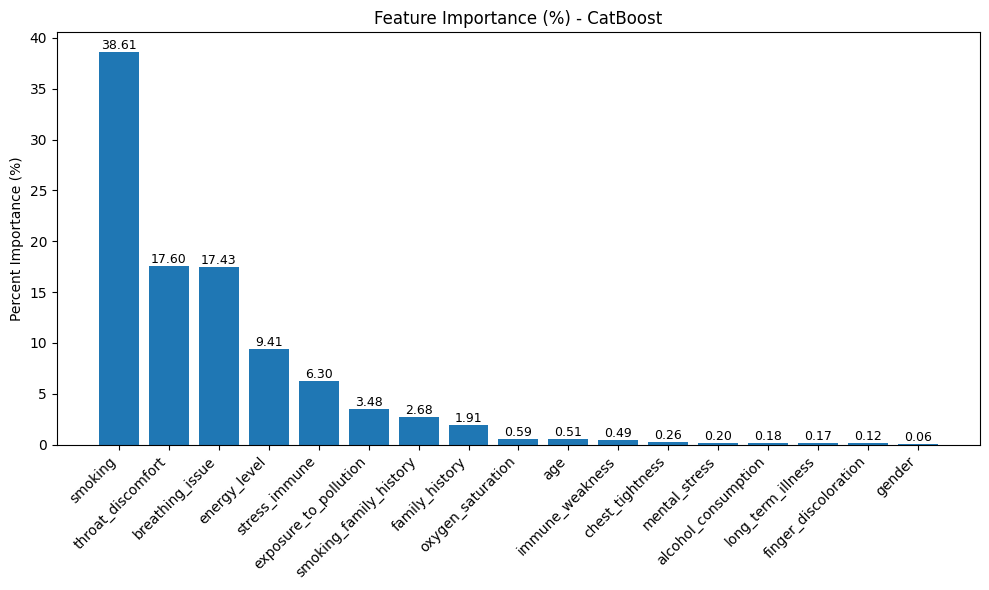


Saved: feature_importance_catboost.png


In [ ]:
# =========================
# 6 FEATURE IMPORTANCE (LossFunctionChange) trên tậ TRAIN
# =========================
train_pool = Pool(
    X_train_full,
    label=y_train_full
)

# Lấy độ quan trọng
importances = cat_full.get_feature_importance(
    data=train_pool,
    type="LossFunctionChange"
)

feat_labels = X_train_full.columns

# Tạo dataframe
imp_df = pd.DataFrame({
    "Feature": feat_labels,
    "Importance": importances
})

imp_df["Percent_Importance (%)"] = (
    imp_df["Importance"] / imp_df["Importance"].sum() * 100
).round(2)

# Sắp xếp giảm dần
imp_df = imp_df.sort_values(
    by="Percent_Importance (%)",
    ascending=False
).reset_index(drop=True)

print("\n===== FEATURE IMPORTANCE (SORTED) =====")
print(imp_df)

imp_df.to_csv("/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.5.ChonDacTrung/CatBoost/feature_importance_catboost.csv", index=False)
print("\nSaved: feature_importance_catboost.csv")

# =========================
# VẼ BIỂU ĐỒ CỘT
# =========================
plt.figure(figsize=(10,6))

bars = plt.bar(
    imp_df["Feature"],
    imp_df["Percent_Importance (%)"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Percent Importance (%)")
plt.title("Feature Importance (%) - CatBoost")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.5.ChonDacTrung/CatBoost/feature_importance_catboost.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nSaved: feature_importance_catboost.png")

=========================================================================================================

2. RANDOM FOREST

In [ ]:
rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

rf_full.fit(X_train_full, y_train_full)

# =========================
# ĐÁNH GIÁ RANDOM FOREST
# =========================
y_pred_rf = rf_full.predict(X_test_final)
y_proba_rf = rf_full.predict_proba(X_test_final)[:, 1]

acc_rf  = accuracy_score(y_test_final, y_pred_rf)
prec_rf = precision_score(y_test_final, y_pred_rf)
rec_rf  = recall_score(y_test_final, y_pred_rf)
f1_rf   = f1_score(y_test_final, y_pred_rf)
auc_rf  = roc_auc_score(y_test_final, y_proba_rf)

print("\n===== RANDOM FOREST RESULT =====")
print("Accuracy :", round(acc_rf, 4))
print("Precision:", round(prec_rf, 4))
print("Recall   :", round(rec_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("AUC      :", round(auc_rf, 4))


===== RANDOM FOREST RESULT =====
Accuracy : 0.904
Precision: 0.8821
Recall   : 0.8821
F1 Score : 0.8821
AUC      : 0.9213



===== FEATURE IMPORTANCE (SORTED) =====
                   Feature  Importance  Percent_Importance (%)
0                  smoking    0.242875                   24.29
1             energy_level    0.140428                   14.04
2          breathing_issue    0.114719                   11.47
3        throat_discomfort    0.112841                   11.28
4        oxygen_saturation    0.079906                    7.99
5                      age    0.068205                    6.82
6   smoking_family_history    0.053119                    5.31
7            stress_immune    0.035432                    3.54
8    exposure_to_pollution    0.030938                    3.09
9           family_history    0.022469                    2.25
10         immune_weakness    0.018625                    1.86
11           mental_stress    0.015488                    1.55
12     alcohol_consumption    0.013278                    1.33
13       long_term_illness    0.013059                    1.31
14            

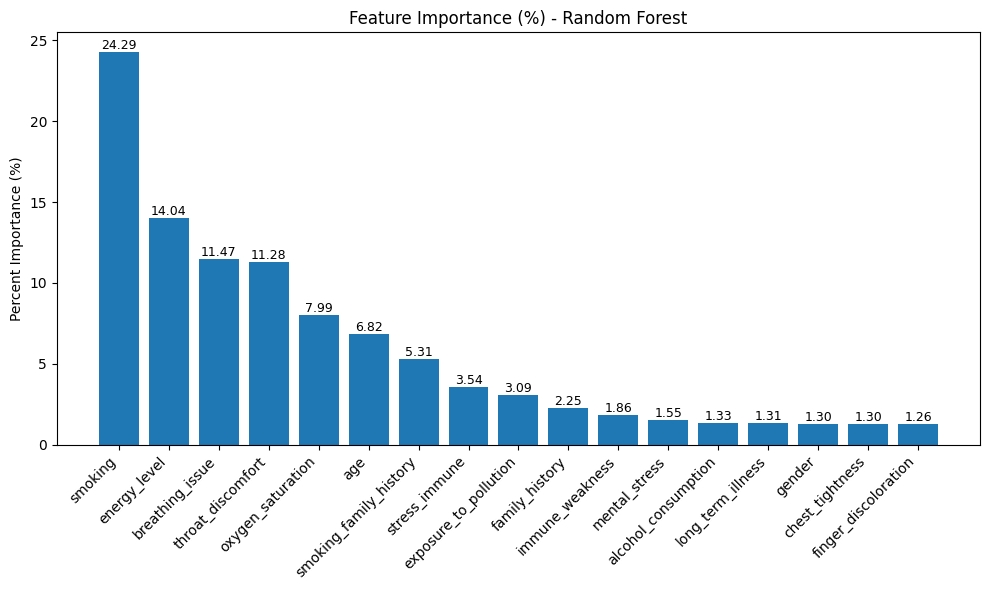


Saved: feature_importance_random_forest.png


In [ ]:
# =========================
# 6 FEATURE IMPORTANCE trên tập TRAIN (Random Forest)
# =========================

# Lấy độ quan trọng
importances = rf_full.feature_importances_

feat_labels = X_train_full.columns

# Tạo dataframe
imp_df = pd.DataFrame({
    "Feature": feat_labels,
    "Importance": importances
})

imp_df["Percent_Importance (%)"] = (
    imp_df["Importance"] / imp_df["Importance"].sum() * 100
).round(2)

# Sắp xếp giảm dần
imp_df = imp_df.sort_values(
    by="Percent_Importance (%)",
    ascending=False
).reset_index(drop=True)

print("\n===== FEATURE IMPORTANCE (SORTED) =====")
print(imp_df)

imp_df.to_csv("/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.5.ChonDacTrung/Random Forest/feature_importance_random_forest.csv", index=False)
print("\nSaved: feature_importance_random_forest.csv")

# =========================
# VẼ BIỂU ĐỒ CỘT
# =========================
plt.figure(figsize=(10,6))

bars = plt.bar(
    imp_df["Feature"],
    imp_df["Percent_Importance (%)"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Percent Importance (%)")
plt.title("Feature Importance (%) - Random Forest")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.5.ChonDacTrung/Random Forest/feature_importance_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nSaved: feature_importance_random_forest.png")

=========================================================================================================

3. Bagging Tree

In [ ]:
bagging_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        criterion='entropy'
    ),
    n_estimators=300,
    bootstrap=True,
    random_state=42,
    n_jobs=8
)

bagging_dt.fit(X_train_full, y_train_full)

# =========================
# ĐÁNH GIÁ BAGGING DT
# =========================
y_pred_bag = bagging_dt.predict(X_test_final)
y_proba_bag = bagging_dt.predict_proba(X_test_final)[:, 1]

acc_bag  = accuracy_score(y_test_final, y_pred_bag)
prec_bag = precision_score(y_test_final, y_pred_bag)
rec_bag  = recall_score(y_test_final, y_pred_bag)
f1_bag   = f1_score(y_test_final, y_pred_bag)
auc_bag  = roc_auc_score(y_test_final, y_proba_bag)

print("\n===== BAGGING DECISION TREE RESULT =====")
print("Accuracy :", round(acc_bag, 4))
print("Precision:", round(prec_bag, 4))
print("Recall   :", round(rec_bag, 4))
print("F1 Score :", round(f1_bag, 4))
print("AUC      :", round(auc_bag, 4))


===== BAGGING DECISION TREE RESULT =====
Accuracy : 0.903
Precision: 0.8799
Recall   : 0.8821
F1 Score : 0.881
AUC      : 0.909



===== FEATURE IMPORTANCE (SORTED) =====
                   Feature  Importance  Percent_Importance (%)
0                  smoking    0.259617                   25.96
1             energy_level    0.154830                   15.48
2        throat_discomfort    0.127442                   12.74
3          breathing_issue    0.125505                   12.55
4            stress_immune    0.085944                    8.59
5        oxygen_saturation    0.059961                    6.00
6    exposure_to_pollution    0.046732                    4.67
7                      age    0.042303                    4.23
8           family_history    0.030442                    3.04
9   smoking_family_history    0.029579                    2.96
10                  gender    0.006749                    0.67
11       long_term_illness    0.006058                    0.61
12     alcohol_consumption    0.005492                    0.55
13    finger_discoloration    0.005403                    0.54
14         che

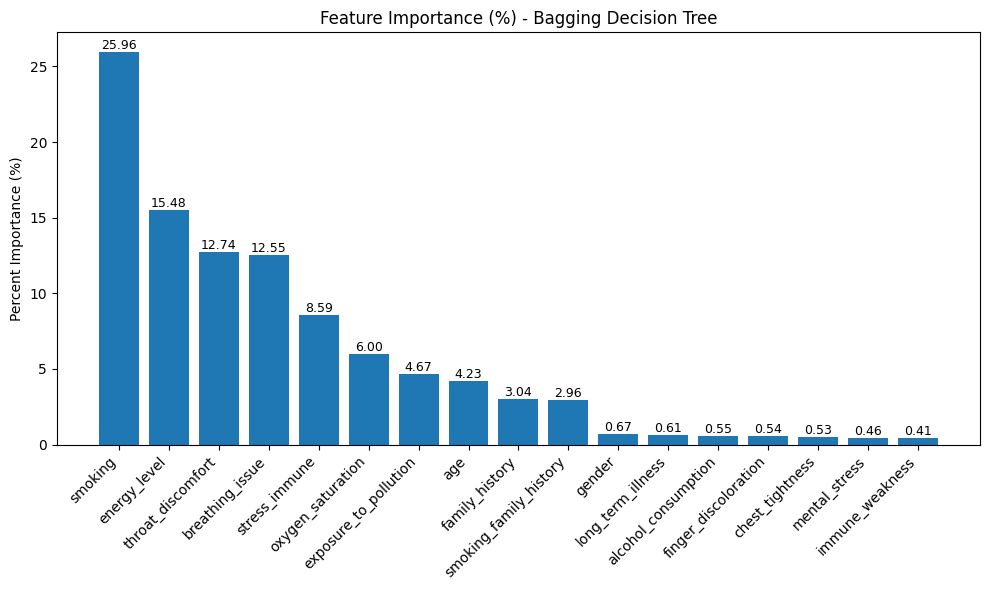


Saved: feature_importance_bagging_dt.png


In [ ]:
# =========================
# 6 FEATURE IMPORTANCE trên tập TRAIN (Bagging Decision Tree)
# =========================

# Lấy importance trung bình từ tất cả cây
importances = np.mean(
    [tree.feature_importances_ for tree in bagging_dt.estimators_],
    axis=0
)

feat_labels = X_train_full.columns

# Tạo dataframe
imp_df = pd.DataFrame({
    "Feature": feat_labels,
    "Importance": importances
})

imp_df["Percent_Importance (%)"] = (
    imp_df["Importance"] / imp_df["Importance"].sum() * 100
).round(2)

# Sắp xếp giảm dần
imp_df = imp_df.sort_values(
    by="Percent_Importance (%)",
    ascending=False
).reset_index(drop=True)

print("\n===== FEATURE IMPORTANCE (SORTED) =====")
print(imp_df)

imp_df.to_csv("/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.5.ChonDacTrung/Bagging Decision Tree/feature_importance_bagging_dt.csv", index=False)
print("\nSaved: feature_importance_bagging_dt.csv")

# =========================
# VẼ BIỂU ĐỒ CỘT
# =========================
plt.figure(figsize=(10,6))

bars = plt.bar(
    imp_df["Feature"],
    imp_df["Percent_Importance (%)"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Percent Importance (%)")
plt.title("Feature Importance (%) - Bagging Decision Tree")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.5.ChonDacTrung/Bagging Decision Tree/feature_importance_bagging_dt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved: feature_importance_bagging_dt.png")